# DeepSEA transfer learning: human &rarr; mouse &mdash; all three conditions in one notebook

This is the merged version of the three original notebooks
(`Deepsea_Transfer_Learning_Mouse`, `Deepsea_Scratch_Learning_Mouse`,
`Deepsea_prediction_baseline_mouse`). They only ever differed in two config
flags, so here they are a single `CONDITIONS` loop:

| condition | human weights | epochs | meaning |
|---|---|---|---|
| **transfer** | yes | 10 | human conv trunk + fine-tune (the method) |
| **scratch**  | no  | 10 | random trunk + train (ablation) |
| **baseline** | yes | 0  | human trunk + untrained head, eval only (zero-shot floor) |

Everything else (model, data split, metrics, plots) is shared, so the
comparison stays valid by construction &mdash; you can no longer let the three
drift apart.

**Saving weights (Colab-in-VSCode).** The Colab VM filesystem is wiped when the
runtime recycles, and `google.colab.files.download` is unreliable through the
VSCode extension. So by default this notebook **mounts Google Drive** and writes
every model's weights, metrics, and figures under `MyDrive/deepsea_transfer_runs`.
Set `MOUNT_DRIVE = False` to keep results on the local VM only.

In [ ]:
# --- environment (Colab / Colab-in-VSCode) ---
# torch is preinstalled on Colab. Install the rest.
!pip -q install pyfaidx scikit-learn matplotlib requests scipy
import torch, numpy as np, matplotlib.pyplot as plt, os, io, json, time
import torch.nn as nn, requests
from sklearn.metrics import roc_auc_score, average_precision_score
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available())

torch 2.11.0+cu128 | CUDA: True


In [ ]:
# ============================ CONFIG ============================
DATA_NPZ          = "mouse_encode_data/mouse_demo.npz"
KIPOI_WEIGHTS_URL = "https://zenodo.org/record/1466993/files/deepsea_predict.pth?download=1"

# Shared model / training settings -- IDENTICAL across all conditions so the
# comparison stays valid. Only the per-condition flags in CONDITIONS may differ.
FREEZE_TRUNK   = False      # True -> linear-probe (frozen trunk); False -> fine-tune all
TRUNK_POOL     = "flatten"  # "avgmax" (small head, recommended) | "flatten" (orig 50880-wide head, overfits)
TEST_CHROM     = "chr19"
VAL_CHROM      = "chr18"    # set None to use VAL_FRACTION off the training chroms
VAL_FRACTION   = 0.1
PATIENCE       = 3
BATCH          = 256
LR_HEAD        = 1e-3
LR_TRUNK       = 1e-4       # smaller LR for the pretrained trunk
WD_HEAD        = 1e-2
WD_TRUNK       = 1e-4
SEED           = 0

# The three experiments that used to be three notebooks. The contrast IS the result.
CONDITIONS = [
    {"name": "transfer", "use_human_weights": True,  "epochs": 10},  # human trunk + fine-tune (the method)
    {"name": "scratch",  "use_human_weights": False, "epochs": 10},  # random trunk + train (ablation)
    {"name": "baseline", "use_human_weights": True,  "epochs": 0},   # human trunk + untrained head (zero-shot floor)
]

# ---- where to persist weights / metrics / figures ----
MOUNT_DRIVE  = True
DRIVE_SUBDIR = "deepsea_transfer_runs"      # folder created under MyDrive
if MOUNT_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        OUTPUT_DIR = f"/content/drive/MyDrive/{DRIVE_SUBDIR}"
    except Exception as e:
        print("Drive mount failed -> saving to local ./runs instead.\n  reason:", e)
        OUTPUT_DIR = "runs"
else:
    OUTPUT_DIR = "runs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("outputs ->", OUTPUT_DIR)

torch.manual_seed(SEED); np.random.seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

Mounted at /content/drive
outputs -> /content/drive/MyDrive/deepsea_transfer_runs


## Step 1 &mdash; build the dataset (run once)

`--max-features 300` is a **ceiling**; the live ENCODE data currently yields ~133
`(biosample, target)` features. Dry-run first, then build only if the `.npz` is
missing (the build is a multi-GB download; use a High-RAM runtime).

In [ ]:
!git clone https://github.com/ericxu1070/DeepSEA-Transfer-Learning.git
%cd "DeepSEA-Transfer-Learning/Mouse Transfer Learning"

Cloning into 'DeepSEA-Transfer-Learning'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 31 (delta 2), reused 30 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 902.43 KiB | 3.73 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/DeepSEA-Transfer-Learning/Mouse Transfer Learning


In [ ]:
# Verify the query before downloading anything.
!python download_mouse_encode.py --dry-run --biosamples liver heart forebrain CH12.LX MEL --max-features 300

Querying ENCODE (mm10, biosamples=['liver', 'heart', 'forebrain', 'CH12.LX', 'MEL']) ...
[liver / TF ChIP-seq] 63 narrowPeak files matched
[liver / Histone ChIP-seq] 528 narrowPeak files matched
[liver / DNase-seq] 116 narrowPeak files matched
[heart / TF ChIP-seq] 49 narrowPeak files matched
[heart / Histone ChIP-seq] 584 narrowPeak files matched
[heart / DNase-seq] 75 narrowPeak files matched
[forebrain / TF ChIP-seq] 9 narrowPeak files matched
[forebrain / Histone ChIP-seq] 496 narrowPeak files matched
[forebrain / DNase-seq] 21 narrowPeak files matched
[CH12.LX / TF ChIP-seq] 345 narrowPeak files matched
[CH12.LX / Histone ChIP-seq] 104 narrowPeak files matched
[CH12.LX / DNase-seq] 6 narrowPeak files matched
[MEL / TF ChIP-seq] 438 narrowPeak files matched
[MEL / Histone ChIP-seq] 136 narrowPeak files matched
[MEL / DNase-seq] 15 narrowPeak files matched

133 features across 5 biosamples:
    CH12.LX: 48
    MEL: 48
    forebrain: 10
    heart: 13
    liver: 14

NOTE: found 133 fe

In [ ]:
# Build only if the dataset isn't already present (rebuilding is a multi-GB download).
if not os.path.exists(DATA_NPZ):
    !python download_mouse_encode.py --chroms all --biosamples liver heart forebrain CH12.LX MEL --max-features 300 --max-samples 1000000 --skip-selene
else:
    print(DATA_NPZ, "already exists -- skipping rebuild.")

Querying ENCODE (mm10, biosamples=['liver', 'heart', 'forebrain', 'CH12.LX', 'MEL']) ...
[liver / TF ChIP-seq] 63 narrowPeak files matched
[liver / Histone ChIP-seq] 528 narrowPeak files matched
[liver / DNase-seq] 116 narrowPeak files matched
[heart / TF ChIP-seq] 49 narrowPeak files matched
[heart / Histone ChIP-seq] 584 narrowPeak files matched
[heart / DNase-seq] 75 narrowPeak files matched
[forebrain / TF ChIP-seq] 9 narrowPeak files matched
[forebrain / Histone ChIP-seq] 496 narrowPeak files matched
[forebrain / DNase-seq] 21 narrowPeak files matched
[CH12.LX / TF ChIP-seq] 345 narrowPeak files matched
[CH12.LX / Histone ChIP-seq] 104 narrowPeak files matched
[CH12.LX / DNase-seq] 6 narrowPeak files matched
[MEL / TF ChIP-seq] 438 narrowPeak files matched
[MEL / Histone ChIP-seq] 136 narrowPeak files matched
[MEL / DNase-seq] 15 narrowPeak files matched

133 features across 5 biosamples:
    CH12.LX: 48
    MEL: 48
    forebrain: 10
    heart: 13
    liver: 14

NOTE: found 133 fe

## Step 2 &mdash; load data and split by chromosome (once)

In [ ]:
assert os.path.exists(DATA_NPZ), (
    f"{DATA_NPZ} not found. Run the two download cells above first.")

d = np.load(DATA_NPZ, allow_pickle=True)
seq_idx  = d["seq_idx"]                        # (N, 1000) uint8 in {0..4}
labels   = d["labels"].astype(np.float32)      # (N, F)
chrom    = d["chrom"]
features = list(d["features"])
F = labels.shape[1]
print(f"samples={seq_idx.shape[0]:,}  window={seq_idx.shape[1]}  features={F}")
print("positives/feature (min/median/max):",
      int(labels.sum(0).min()), int(np.median(labels.sum(0))), int(labels.sum(0).max()))

is_test = chrom == TEST_CHROM
if is_test.sum() == 0 or is_test.sum() == len(chrom):
    print(f"WARNING: TEST_CHROM={TEST_CHROM!r} not separable "
          f"(test bins={int(is_test.sum())} of {len(chrom)}). "
          "Using a positional 80/10/10 split; download >=2 chroms for a clean test.")
    n = len(seq_idx); idx = np.arange(n)
    c1, c2 = int(0.8*n), int(0.9*n)
    tr_i, va_i, te_i = idx[:c1], idx[c1:c2], idx[c2:]
else:
    te_i = np.where(is_test)[0]
    if VAL_CHROM is not None and (chrom == VAL_CHROM).sum() > 0:
        va_i = np.where(chrom == VAL_CHROM)[0]
        tr_i = np.where(~is_test & (chrom != VAL_CHROM))[0]
        print(f"held-out chroms -> test:{TEST_CHROM} ({len(te_i):,})  "
              f"val:{VAL_CHROM} ({len(va_i):,})")
    else:
        rest = np.where(~is_test)[0]
        rng = np.random.default_rng(SEED); rng.shuffle(rest)
        cut = int(len(rest)*(1-VAL_FRACTION))
        tr_i, va_i = rest[:cut], rest[cut:]
        print(f"held-out test:{TEST_CHROM} ({len(te_i):,}); random val split")
print(f"train={len(tr_i):,}  val={len(va_i):,}  test={len(te_i):,}")

samples=1,000,000  window=1000  features=133
positives/feature (min/median/max): 53 13124 245650
held-out chroms -> test:chr19 (25,944)  val:chr18 (29,130)
train=944,926  val=29,130  test=25,944


In [ ]:
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    # Holds index arrays (the selection), not copies of the sequences. One-hot
    # encodes on the fly: idx 4 (N) -> all-zero column. At ~1e6 samples this
    # avoids duplicating the ~1 GB seq array once per split.
    def __init__(self, idx_arr, lab_arr, sel):
        self.idx_arr = idx_arr; self.lab_arr = lab_arr
        self.sel = np.asarray(sel)
    def __len__(self): return len(self.sel)
    def __getitem__(self, i):
        row = self.sel[i]
        s = self.idx_arr[row].astype(np.int64)
        oh = np.zeros((4, len(s)), dtype=np.float32)
        valid = s < 4
        oh[s[valid], np.arange(len(s))[valid]] = 1.0
        return torch.from_numpy(oh), torch.from_numpy(self.lab_arr[row])

def loader(sel, shuffle):
    return DataLoader(SeqDataset(seq_idx, labels, sel), batch_size=BATCH,
                      shuffle=shuffle, num_workers=2, drop_last=shuffle,
                      pin_memory=(device == "cuda"), persistent_workers=True)

train_dl, val_dl, test_dl = loader(tr_i, True), loader(va_i, False), loader(te_i, False)

## Step 3 &mdash; model, human-weight transfer, and train/eval helpers (defined once)

In [ ]:
class DeepSEATrunk(nn.Module):
    # three conv blocks of the original DeepSEA (320/480/960 kernels, k=8).
    # Returns the conv feature map (B, 960, L); pooling/flattening is the head's job.
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(4, 320, 8),   nn.ReLU(inplace=True), nn.MaxPool1d(4, 4), nn.Dropout(0.2),
            nn.Conv1d(320, 480, 8), nn.ReLU(inplace=True), nn.MaxPool1d(4, 4), nn.Dropout(0.2),
            nn.Conv1d(480, 960, 8), nn.ReLU(inplace=True), nn.Dropout(0.5),
        )
    def forward(self, x):                 # x: (B,4,1000)
        return self.conv(x)               # -> (B, 960, L)  (L=53 for 1000-bp input)

class DeepSEATransfer(nn.Module):
    """Trunk + pooled head. pool='avgmax' concatenates length-wise avg and max
    (-> 1920 features, ~1M-param head). pool='flatten' reproduces the original
    50880-wide head, which overfits on a small dataset. The feature dimension is
    inferred from a dummy forward, so it stays correct if pooling/kernels/length change."""
    def __init__(self, n_targets, pool="avgmax", hidden=512, dropout=0.5):
        super().__init__()
        self.trunk = DeepSEATrunk()
        self.pool = pool
        with torch.no_grad():
            feat_dim = self._pool(self.trunk(torch.zeros(1, 4, 1000))).shape[1]
        self.head = nn.Sequential(
            nn.Linear(feat_dim, hidden), nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden), nn.Dropout(dropout),
            nn.Linear(hidden, n_targets),
        )
    def _pool(self, f):                   # f: (B, C, L)
        if self.pool == "flatten":
            return f.flatten(1)
        a = f.mean(-1)
        if self.pool == "avg":
            return a
        return torch.cat([a, f.amax(-1)], dim=1)   # "avgmax"
    def forward(self, x):
        return self.head(self._pool(self.trunk(x)))

In [ ]:
# ---- human (Kipoi) checkpoint -> trunk, by shape-matched order ----
def _state_dict_from(obj):
    if isinstance(obj, nn.Module):
        return obj.state_dict()
    if isinstance(obj, dict):
        for key in ("state_dict", "model_state_dict", "model", "weights"):
            if key in obj and isinstance(obj[key], dict):
                return obj[key]
        return obj
    raise TypeError(f"unrecognized checkpoint type: {type(obj)}")

def _to_conv1d_weight(w):
    # coerce a conv weight to rank-3 (out, in, k) by dropping a singleton dim.
    if w.ndim == 3:
        return w
    if w.ndim == 4:
        for dim in (2, 1):
            if w.shape[dim] == 1:
                return w.squeeze(dim)
    return None

def conv_weights_in_order(state):
    items = list(state.items()); out = []
    for i, (k, v) in enumerate(items):
        if not hasattr(v, "ndim") or v.ndim not in (3, 4):
            continue
        w3 = _to_conv1d_weight(v)
        if w3 is None or w3.ndim != 3:
            continue
        bias = None
        if i + 1 < len(items):
            bk, bv = items[i + 1]
            if hasattr(bv, "ndim") and bv.ndim == 1 and bv.shape[0] == w3.shape[0]:
                bias = bv
        out.append((k, w3, bias))
    return out

_HUMAN_STATE = {}
def get_human_state():
    # download + cache once; transfer and baseline both reuse it.
    if "state" not in _HUMAN_STATE:
        raw = requests.get(KIPOI_WEIGHTS_URL, timeout=180).content
        obj = torch.load(io.BytesIO(raw), map_location="cpu", weights_only=False)  # trusted Zenodo
        _HUMAN_STATE["state"] = _state_dict_from(obj)
    return _HUMAN_STATE["state"]

def load_human_trunk(model, state):
    src = conv_weights_in_order(state)
    dst = [m for m in model.trunk.conv if isinstance(m, nn.Conv1d)]
    n = 0
    for (k, w, b), layer in zip(src, dst):
        ww = w
        if tuple(ww.shape) != tuple(layer.weight.shape) and ww.ndim == 3 \
                and tuple(ww.transpose(1, 2).shape) == tuple(layer.weight.shape):
            ww = ww.transpose(1, 2).contiguous()
        if tuple(ww.shape) == tuple(layer.weight.shape):
            layer.weight.data.copy_(ww)
            if b is not None and tuple(b.shape) == tuple(layer.bias.shape):
                layer.bias.data.copy_(b)
            n += 1
        else:
            raise RuntimeError(f"conv{n+1} shape mismatch ckpt {tuple(w.shape)} "
                               f"vs model {tuple(layer.weight.shape)}")
    if n != len(dst):
        raise RuntimeError(f"only mapped {n}/{len(dst)} conv layers")

In [ ]:
# ---- build / train / evaluate, parameterized by condition ----
def build_model(use_human_weights, freeze_trunk=FREEZE_TRUNK, pool=TRUNK_POOL):
    # Reseed so every condition starts from the SAME head (and, for scratch, the
    # same random trunk) initialization -> a fair comparison.
    torch.manual_seed(SEED); np.random.seed(SEED)
    model = DeepSEATransfer(F, pool=pool).to(device)
    if use_human_weights:
        try:
            load_human_trunk(model, get_human_state()); print("  human trunk loaded")
        except Exception as e:
            print("  WARNING: human weights failed -> random trunk.\n   reason:", e)
    else:
        print("  random trunk (scratch)")
    if freeze_trunk:
        for p in model.trunk.parameters(): p.requires_grad_(False)
        print("  trunk frozen (linear-probe)")
    return model

def run_epoch(model, dl, opt, criterion, train):
    model.train(train); tot, nb = 0.0, 0
    for x, y in dl:
        x, y = x.to(device), y.to(device)
        with torch.set_grad_enabled(train):
            loss = criterion(model(x), y)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item(); nb += 1
    return tot / max(nb, 1)

@torch.no_grad()
def predict(model, dl):
    model.eval(); P, Y = [], []
    for x, y in dl:
        P.append(torch.sigmoid(model(x.to(device))).cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(P), np.concatenate(Y)

def median_auroc(probs, ytrue):
    a = []
    for j in range(ytrue.shape[1]):
        s = ytrue[:, j].sum()
        if s == 0 or s == len(ytrue): continue
        a.append(roc_auc_score(ytrue[:, j], probs[:, j]))
    return float(np.median(a)) if a else float("nan")

def train_model(model, epochs):
    pos = labels[tr_i].sum(0); neg = len(tr_i) - pos
    pos_weight = torch.tensor(np.clip(neg / np.maximum(pos, 1), 1, 100),
                              dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    groups = [{"params": model.head.parameters(), "lr": LR_HEAD, "weight_decay": WD_HEAD}]
    if any(p.requires_grad for p in model.trunk.parameters()):
        groups.append({"params": model.trunk.parameters(), "lr": LR_TRUNK, "weight_decay": WD_TRUNK})
    opt = torch.optim.AdamW(groups)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=2)

    hist = {"train": [], "val": [], "val_auroc": []}
    best_val, best_state, bad = float("inf"), None, 0
    for ep in range(1, epochs + 1):
        tr = run_epoch(model, train_dl, opt, criterion, True)
        vl = run_epoch(model, val_dl, opt, criterion, False)
        vp, vy = predict(model, val_dl); va = median_auroc(vp, vy)   # convergence tracking
        sched.step(vl)
        hist["train"].append(tr); hist["val"].append(vl); hist["val_auroc"].append(va)
        print(f"  epoch {ep:2d}  train {tr:.4f}  val {vl:.4f}  val_AUROC {va:.3f}  "
              f"lr {opt.param_groups[0]['lr']:.2e}")
        if vl < best_val - 1e-4:
            best_val = vl; bad = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE:
                print(f"  early stop at epoch {ep} (best val {best_val:.4f})"); break
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"  restored best model (val loss {best_val:.4f})")
    return hist, best_val

def evaluate(model):
    probs, ytrue = predict(model, test_dl)
    auroc, auprc, kept = [], [], []
    for j, f in enumerate(features):
        s = ytrue[:, j].sum()
        if s == 0 or s == len(ytrue): continue   # undefined with no +/- in test
        auroc.append(roc_auc_score(ytrue[:, j], probs[:, j]))
        auprc.append(average_precision_score(ytrue[:, j], probs[:, j]))
        kept.append(f)
    return probs, ytrue, np.array(auroc), np.array(auprc), kept

## Step 4 &mdash; run all three conditions and save weights

Each condition trains a fresh model, evaluates on the held-out test chromosome,
and writes `<name>_model.pt` (weights) + `<name>_metrics.npz` to `OUTPUT_DIR`.
Re-running is cheap to resume from these files if you ever need to.

In [ ]:
results = {}
for cfg in CONDITIONS:
    name = cfg["name"]
    print(f"\n===== {name}  (human={cfg['use_human_weights']}, epochs={cfg['epochs']}) =====")
    t0 = time.time()
    model = build_model(cfg["use_human_weights"])
    hist, best_val = train_model(model, cfg["epochs"])
    probs, ytrue, auroc, auprc, kept = evaluate(model)
    print(f"  [{name}] evaluable {len(kept)}/{F}  "
          f"median AUROC {np.median(auroc):.3f}  median AUPRC {np.median(auprc):.3f}  "
          f"({time.time()-t0:.0f}s)")

    # ---- persist weights + metrics ----
    torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, f"{name}_model.pt"))
    np.savez(os.path.join(OUTPUT_DIR, f"{name}_metrics.npz"),
             auroc=auroc, auprc=auprc, kept=np.array(kept, dtype=object),
             hist_train=np.array(hist["train"]), hist_val=np.array(hist["val"]),
             hist_val_auroc=np.array(hist["val_auroc"]),
             test_pos_rate=ytrue.mean(0))

    results[name] = {"hist": hist, "auroc": auroc, "auprc": auprc,
                     "kept": kept, "probs": probs, "ytrue": ytrue}
    del model
    if device == "cuda": torch.cuda.empty_cache()

print("\nsaved weights + metrics to", OUTPUT_DIR)


===== transfer  (human=True, epochs=10) =====
  human trunk loaded
  epoch  1  train 0.8802  val 0.7919  val_AUROC 0.846  lr 1.00e-03
  epoch  2  train 0.7633  val 0.7245  val_AUROC 0.869  lr 1.00e-03
  epoch  3  train 0.7113  val 0.7171  val_AUROC 0.877  lr 1.00e-03
  epoch  4  train 0.6745  val 0.7036  val_AUROC 0.882  lr 1.00e-03
  epoch  5  train 0.6450  val 0.7027  val_AUROC 0.885  lr 1.00e-03
  epoch  6  train 0.6221  val 0.7073  val_AUROC 0.886  lr 1.00e-03
  epoch  7  train 0.6024  val 0.7361  val_AUROC 0.883  lr 1.00e-03
  epoch  8  train 0.5863  val 0.7389  val_AUROC 0.884  lr 5.00e-04
  early stop at epoch 8 (best val 0.7027)
  restored best model (val loss 0.7027)
  [transfer] evaluable 133/133  median AUROC 0.884  median AUPRC 0.250  (2404s)

===== scratch  (human=False, epochs=10) =====
  random trunk (scratch)
  epoch  1  train 0.9637  val 0.9828  val_AUROC 0.762  lr 1.00e-03
  epoch  2  train 0.8940  val 0.8626  val_AUROC 0.799  lr 1.00e-03
  epoch  3  train 0.8540  va

## Step 5 &mdash; per-condition figures (the originals, one set per condition)

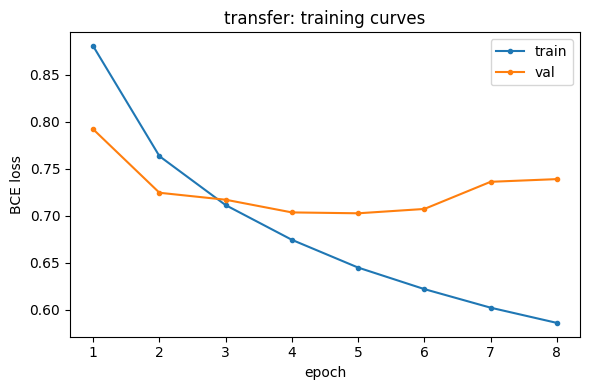

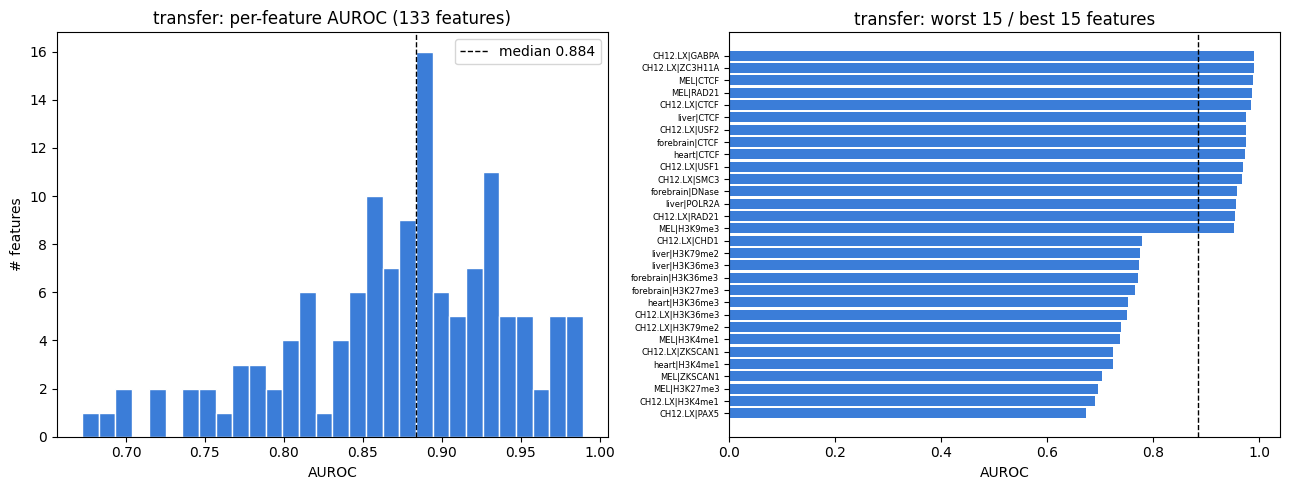

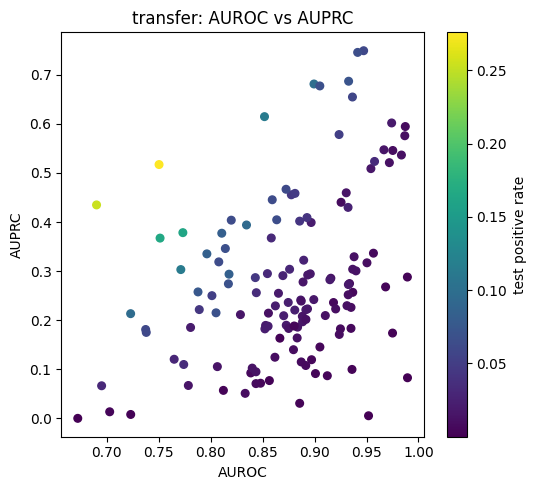

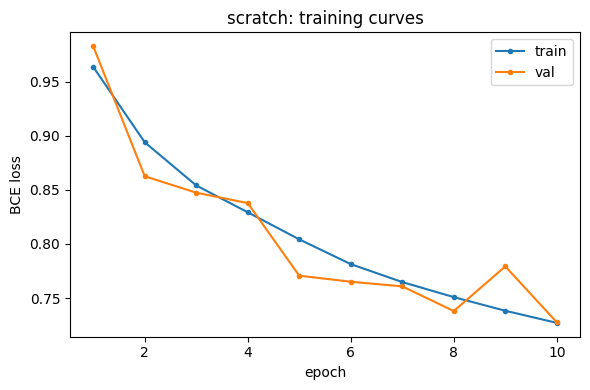

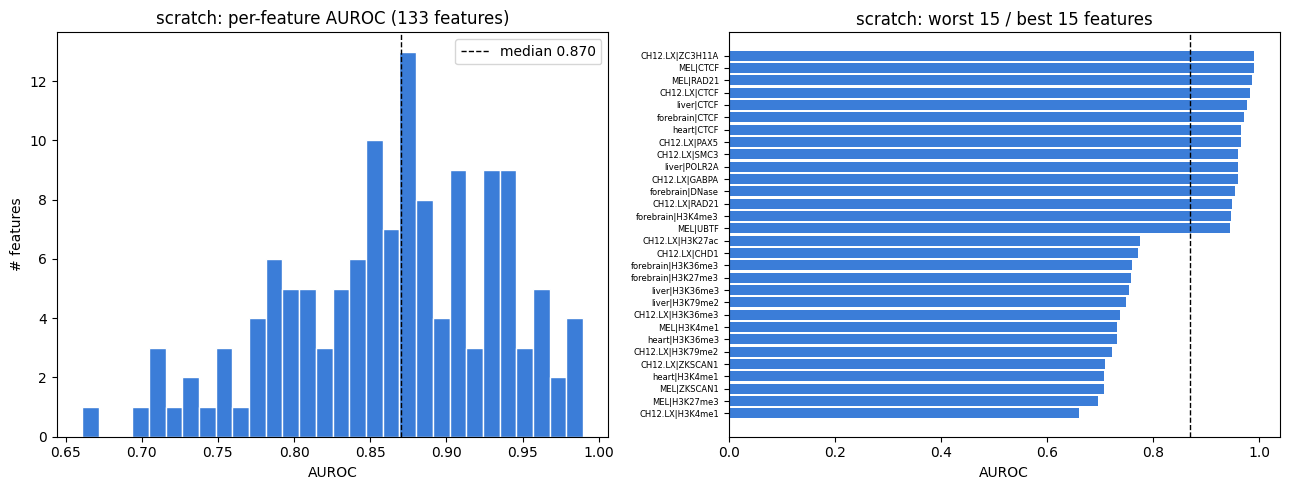

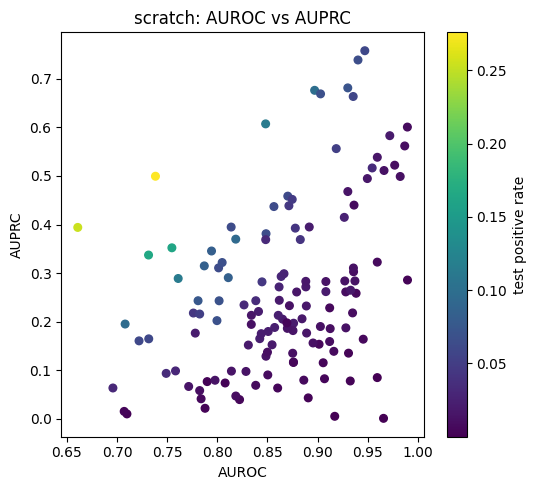

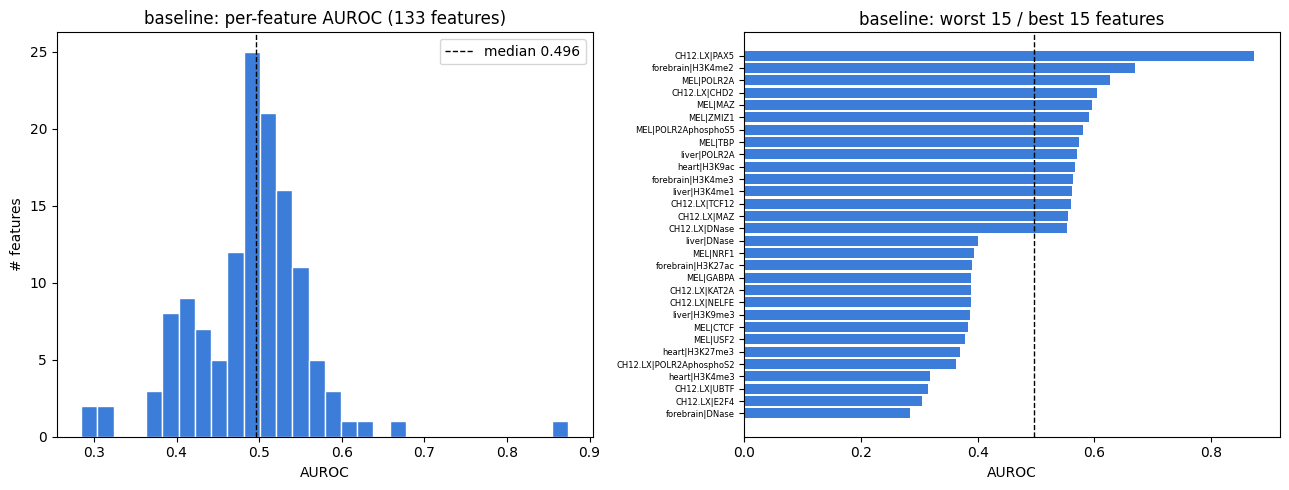

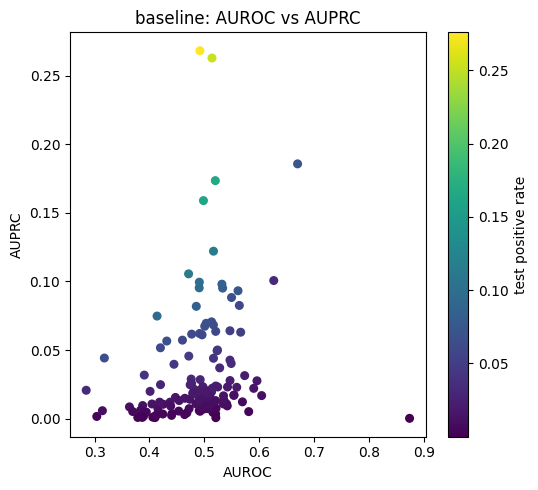

In [ ]:
def plot_condition(name, res):
    hist, auroc, auprc = res["hist"], res["auroc"], res["auprc"]
    kept, ytrue = res["kept"], res["ytrue"]

    if len(hist["train"]):                                   # training curves
        plt.figure(figsize=(6, 4))
        ep = range(1, len(hist["train"]) + 1)
        plt.plot(ep, hist["train"], "-o", label="train", ms=3)
        plt.plot(ep, hist["val"],   "-o", label="val",   ms=3)
        plt.xlabel("epoch"); plt.ylabel("BCE loss")
        plt.title(f"{name}: training curves"); plt.legend(); plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, f"{name}_training_curves.png"), dpi=150); plt.show()

    order = np.argsort(auroc)                                # AUROC hist + best/worst
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    ax[0].hist(auroc, bins=30, color="#3b7dd8", edgecolor="white")
    ax[0].axvline(np.median(auroc), color="k", ls="--", lw=1,
                  label=f"median {np.median(auroc):.3f}")
    ax[0].set(xlabel="AUROC", ylabel="# features",
              title=f"{name}: per-feature AUROC ({len(kept)} features)"); ax[0].legend()
    k = min(15, len(kept))
    tb = np.concatenate([order[:k], order[-k:]]) if len(kept) > 2*k else order
    ax[1].barh(range(len(tb)), auroc[tb], color="#3b7dd8")
    ax[1].axvline(np.median(auroc), color="k", ls="--", lw=1)
    ax[1].set_yticks(range(len(tb)))
    ax[1].set_yticklabels([kept[i] for i in tb], fontsize=6)
    ax[1].set(xlabel="AUROC", title=f"{name}: worst {k} / best {k} features")
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, f"{name}_auroc.png"), dpi=150); plt.show()

    plt.figure(figsize=(5.5, 5))                             # AUROC vs AUPRC
    plt.scatter(auroc, auprc, c=ytrue[:, [features.index(x) for x in kept]].mean(0),
                cmap="viridis", s=30)
    plt.colorbar(label="test positive rate")
    plt.xlabel("AUROC"); plt.ylabel("AUPRC"); plt.title(f"{name}: AUROC vs AUPRC")
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, f"{name}_auroc_vs_auprc.png"), dpi=150); plt.show()

for name in results:
    plot_condition(name, results[name])

## Step 6 &mdash; cross-condition comparison (this is the payoff of merging)

These figures could not exist when the conditions lived in separate notebooks.
The **transfer signal** is the gap between `transfer` and `scratch`/`baseline`.

In [ ]:
def assay_class(feat):
    # feature strings are "biosample|target", e.g. liver|CTCF, heart|H3K27ac
    target = feat.split("|")[-1]
    if target.upper().startswith("DNASE"): return "DNase"
    if target.startswith("H") and ("me" in target or "ac" in target): return "Histone"
    return "TF"

# ---- summary table ----
print(f"{'condition':<10}{'#feat':>7}{'medAUROC':>10}{'medAUPRC':>10}")
summary = {}
for name in results:
    a, p = results[name]["auroc"], results[name]["auprc"]
    summary[name] = {"n_features": int(len(a)),
                     "median_auroc": float(np.median(a)),
                     "median_auprc": float(np.median(p))}
    print(f"{name:<10}{len(a):>7}{np.median(a):>10.3f}{np.median(p):>10.3f}")
with open(os.path.join(OUTPUT_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

# feature set is identical across conditions (same test set), but intersect to be safe
common = [f for f in results["transfer"]["kept"]
          if all(f in results[n]["kept"] for n in results)]
def auroc_for(name):
    idx = {f: i for i, f in enumerate(results[name]["kept"])}
    return np.array([results[name]["auroc"][idx[f]] for f in common])
cls = np.array([assay_class(f) for f in common])

condition   #feat  medAUROC  medAUPRC
transfer      133     0.884     0.250
scratch       133     0.870     0.228
baseline      133     0.496     0.019


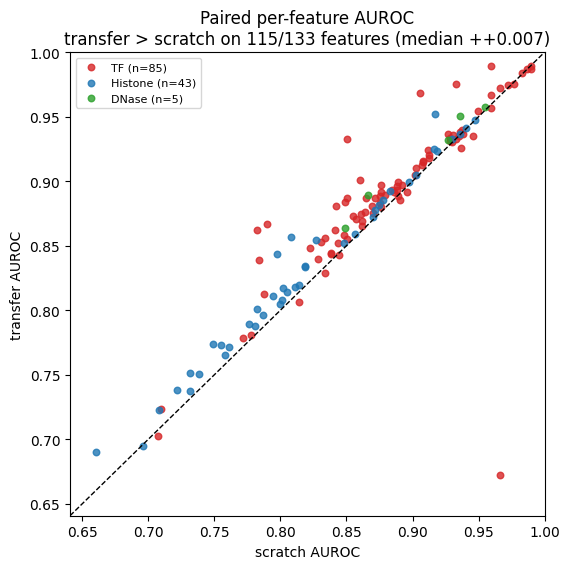

Wilcoxon signed-rank (transfer vs scratch AUROC): stat=625.0  p=7.80e-18


In [ ]:
# ---- paired per-feature scatter: transfer vs scratch ----
if "transfer" in results and "scratch" in results:
    xs, ys = auroc_for("scratch"), auroc_for("transfer")
    colors = {"TF": "#d62728", "Histone": "#1f77b4", "DNase": "#2ca02c"}
    plt.figure(figsize=(5.8, 5.8))
    for c, col in colors.items():
        m = cls == c
        if m.any():
            plt.scatter(xs[m], ys[m], s=22, alpha=.8, color=col, label=f"{c} (n={int(m.sum())})")
    lo, hi = min(xs.min(), ys.min()) - 0.02, 1.0
    plt.plot([lo, hi], [lo, hi], "k--", lw=1)
    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.xlabel("scratch AUROC"); plt.ylabel("transfer AUROC")
    win = int((ys > xs).sum())
    plt.title(f"Paired per-feature AUROC\ntransfer > scratch on {win}/{len(common)} features "
              f"(median +{np.median(ys-xs):+.3f})")
    plt.legend(fontsize=8); plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "compare_paired_auroc.png"), dpi=150); plt.show()
    try:
        from scipy.stats import wilcoxon
        stat, pv = wilcoxon(ys, xs)
        print(f"Wilcoxon signed-rank (transfer vs scratch AUROC): stat={stat:.1f}  p={pv:.2e}")
    except Exception as e:
        print("wilcoxon skipped:", e)

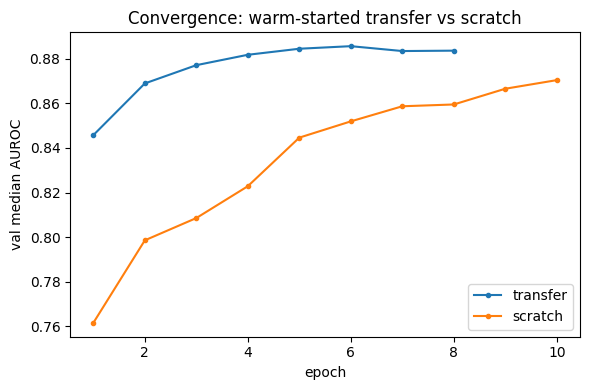

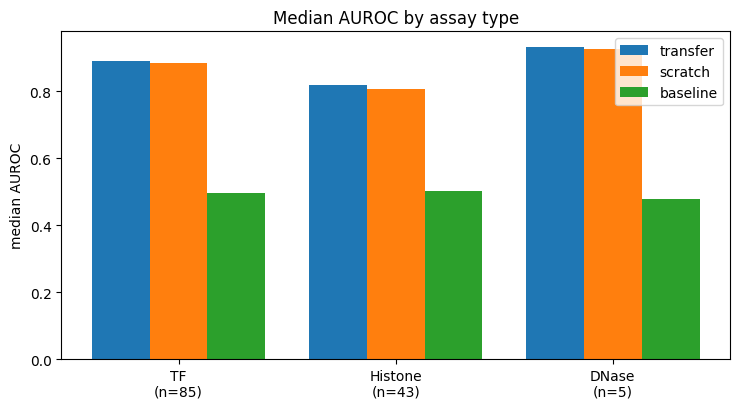

all comparison figures saved to /content/drive/MyDrive/deepsea_transfer_runs


In [ ]:
# ---- convergence overlay: val median AUROC per epoch ----
plt.figure(figsize=(6, 4))
for name in results:
    va = results[name]["hist"]["val_auroc"]
    if len(va):
        plt.plot(range(1, len(va) + 1), va, "-o", ms=3, label=name)
plt.xlabel("epoch"); plt.ylabel("val median AUROC")
plt.title("Convergence: warm-started transfer vs scratch"); plt.legend()
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "compare_convergence.png"), dpi=150); plt.show()

# ---- median AUROC by assay type, per condition ----
classes = ["TF", "Histone", "DNase"]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
names = list(results); width = 0.8 / len(names); x = np.arange(len(classes))
for i, name in enumerate(names):
    a = auroc_for(name)
    meds = [np.median(a[cls == c]) if (cls == c).any() else np.nan for c in classes]
    ax.bar(x + i*width, meds, width, label=name)
ax.set_xticks(x + width*(len(names)-1)/2)
ax.set_xticklabels([f"{c}\n(n={int((cls==c).sum())})" for c in classes])
ax.set_ylabel("median AUROC"); ax.set_title("Median AUROC by assay type")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "compare_by_assay.png"), dpi=150); plt.show()
print("all comparison figures saved to", OUTPUT_DIR)

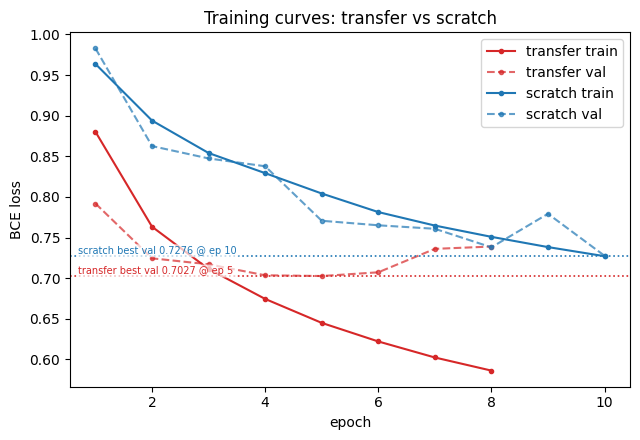

In [ ]:
# ---- loss-curve overlay: train + val BCE for transfer vs scratch on one plot ----
fig, ax = plt.subplots(figsize=(6.5, 4.5))
colors = {"transfer": "#d62728", "scratch": "#1f77b4"}
for name in ("transfer", "scratch"):
    if name not in results:
        continue
    hist = results[name]["hist"]
    if not len(hist["train"]):
        continue
    ep = range(1, len(hist["train"]) + 1)
    c = colors.get(name)
    ax.plot(ep, hist["train"], "-o", color=c, ms=3, label=f"{name} train")
    ax.plot(ep, hist["val"],   "--o", color=c, ms=3, alpha=0.7, label=f"{name} val")
    # mark the lowest validation loss
    best_ep = int(np.argmin(hist["val"])) + 1
    best_vl = float(np.min(hist["val"]))
    ax.axhline(best_vl, color=c, ls=":", lw=1.2)
    # label anchored to the left edge, just above its line, with a readable backing box
    ax.text(0.015, best_vl, f"{name} best val {best_vl:.4f} @ ep {best_ep}",
            transform=ax.get_yaxis_transform(), color=c, fontsize=7,
            va="bottom", ha="left",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))
ax.set_xlabel("epoch"); ax.set_ylabel("BCE loss")
ax.set_title("Training curves: transfer vs scratch")
ax.legend(); fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "compare_training_curves.png"), dpi=150); plt.show()

In [ ]:
# ---- median AUROC by assay type, per condition: printed table + LaTeX for the report ----
# Reuses `common`, `cls`, and auroc_for() defined in the summary cell above.
classes = ["TF", "Histone", "DNase"]
counts = {c: int((cls == c).sum()) for c in classes}

def med_by_type(name):
    a = auroc_for(name)
    return {c: (float(np.median(a[cls == c])) if (cls == c).any() else float("nan"))
            for c in classes}

table = {name: med_by_type(name) for name in results}

# plain-text table
hdr = f"{'condition':<10}" + "".join(f"{c+f' (n={counts[c]})':>16}" for c in classes) + f"{'all':>10}"
print(hdr); print("-" * len(hdr))
for name in results:
    a = auroc_for(name)
    row = f"{name:<10}" + "".join(f"{table[name][c]:>16.3f}" for c in classes)
    row += f"{float(np.median(a)):>10.3f}"
    print(row)

# LaTeX booktabs table -> paste into the report
print("\n% ---- LaTeX (median AUROC by assay type) ----")
print("\\begin{tabular}{l" + "c" * (len(classes) + 1) + "}")
print("\\toprule")
print("Condition & " + " & ".join(f"{c} (n={counts[c]})" for c in classes) + " & All \\\\")
print("\\midrule")
for name in results:
    a = auroc_for(name)
    cells = " & ".join(f"{table[name][c]:.3f}" for c in classes)
    print(f"{name} & {cells} & {float(np.median(a)):.3f} \\\\")
print("\\bottomrule")
print("\\end{tabular}")

with open(os.path.join(OUTPUT_DIR, "auroc_by_type.json"), "w") as f:
    json.dump({"counts": counts, "median_auroc": table}, f, indent=2)

condition        TF (n=85)  Histone (n=43)     DNase (n=5)       all
--------------------------------------------------------------------
transfer             0.892           0.820           0.932     0.884
scratch              0.885           0.808           0.927     0.870
baseline             0.495           0.501           0.477     0.496

% ---- LaTeX (median AUROC by assay type) ----
\begin{tabular}{lcccc}
\toprule
Condition & TF (n=85) & Histone (n=43) & DNase (n=5) & All \\
\midrule
transfer & 0.892 & 0.820 & 0.932 & 0.884 \\
scratch & 0.885 & 0.808 & 0.927 & 0.870 \\
baseline & 0.495 & 0.501 & 0.477 & 0.496 \\
\bottomrule
\end{tabular}


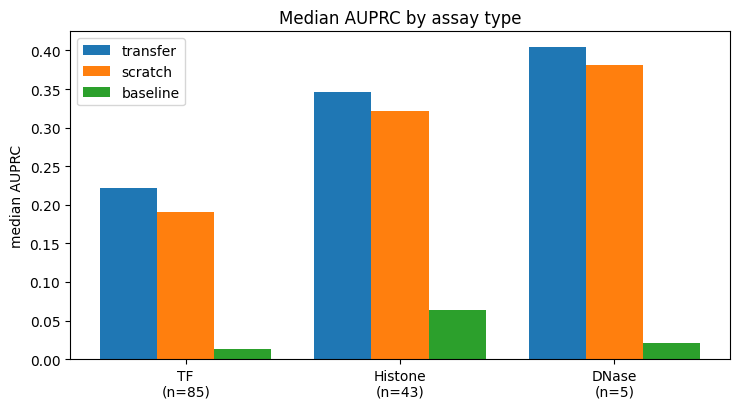

% ---- LaTeX (median AUPRC by assay type) ----
\begin{tabular}{lcccc}
\toprule
Condition & TF (n=85) & Histone (n=43) & DNase (n=5) & All \\
\midrule
transfer & 0.221 & 0.346 & 0.405 & 0.250 \\
scratch & 0.190 & 0.322 & 0.381 & 0.228 \\
baseline & 0.013 & 0.063 & 0.021 & 0.019 \\
\bottomrule
\end{tabular}


In [ ]:
# ---- median AUPRC by assay type, per condition: bar chart + LaTeX table ----
# Companion to the AUROC-by-type cell. AUPRC matters because most features are
# rare-positive, so the report should report both. Reuses common/cls from above.
def auprc_for(name):
    idx = {f: i for i, f in enumerate(results[name]["kept"])}
    return np.array([results[name]["auprc"][idx[f]] for f in common])

classes = ["TF", "Histone", "DNase"]
counts = {c: int((cls == c).sum()) for c in classes}

fig, ax = plt.subplots(figsize=(7.5, 4.2))
names = list(results); width = 0.8 / len(names); x = np.arange(len(classes))
for i, name in enumerate(names):
    p = auprc_for(name)
    meds = [np.median(p[cls == c]) if (cls == c).any() else np.nan for c in classes]
    ax.bar(x + i*width, meds, width, label=name)
ax.set_xticks(x + width*(len(names)-1)/2)
ax.set_xticklabels([f"{c}\n(n={counts[c]})" for c in classes])
ax.set_ylabel("median AUPRC"); ax.set_title("Median AUPRC by assay type")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "compare_auprc_by_assay.png"), dpi=150); plt.show()

print("% ---- LaTeX (median AUPRC by assay type) ----")
print("\\begin{tabular}{l" + "c" * (len(classes) + 1) + "}")
print("\\toprule")
print("Condition & " + " & ".join(f"{c} (n={counts[c]})" for c in classes) + " & All \\\\")
print("\\midrule")
for name in results:
    p = auprc_for(name)
    cells = " & ".join(f"{np.median(p[cls == c]):.3f}" if (cls == c).any() else "--"
                       for c in classes)
    print(f"{name} & {cells} & {float(np.median(p)):.3f} \\\\")
print("\\bottomrule"); print("\\end{tabular}")

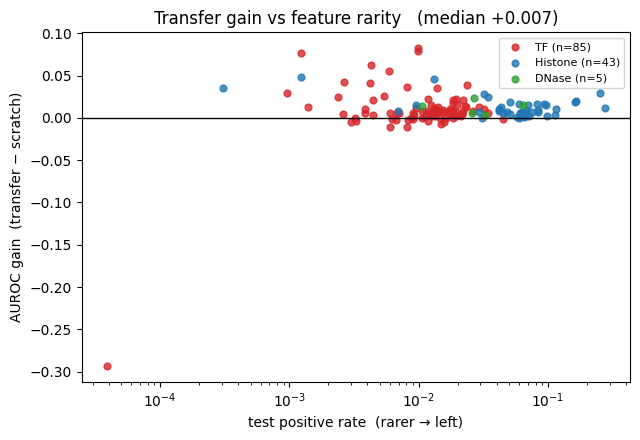

Spearman(gain, positive rate): rho=+0.006  p=9.44e-01  (negative rho -> larger gains on rarer features)


In [ ]:
# ---- per-feature transfer gain vs feature rarity ----
# Does warm-starting help most on rare-positive features? y = AUROC(transfer)
# - AUROC(scratch) per feature; x = its positive rate in the test chrom.
if "transfer" in results and "scratch" in results:
    ytrue = results["transfer"]["ytrue"]              # same test set across conditions
    pos_rate = np.array([ytrue[:, features.index(f)].mean() for f in common])
    delta = auroc_for("transfer") - auroc_for("scratch")
    colmap = {"TF": "#d62728", "Histone": "#1f77b4", "DNase": "#2ca02c"}
    plt.figure(figsize=(6.5, 4.5))
    for c, col in colmap.items():
        m = cls == c
        if m.any():
            plt.scatter(pos_rate[m], delta[m], s=24, alpha=.8, color=col,
                        label=f"{c} (n={int(m.sum())})")
    plt.axhline(0, color="k", lw=1)
    plt.xscale("log")
    plt.xlabel("test positive rate  (rarer → left)")
    plt.ylabel("AUROC gain  (transfer − scratch)")
    plt.title(f"Transfer gain vs feature rarity   (median {np.median(delta):+.3f})")
    plt.legend(fontsize=8); plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "compare_gain_vs_rarity.png"), dpi=150); plt.show()
    try:
        from scipy.stats import spearmanr
        rho, pv = spearmanr(pos_rate, delta)
        print(f"Spearman(gain, positive rate): rho={rho:+.3f}  p={pv:.2e}  "
              "(negative rho -> larger gains on rarer features)")
    except Exception as e:
        print("spearman skipped:", e)

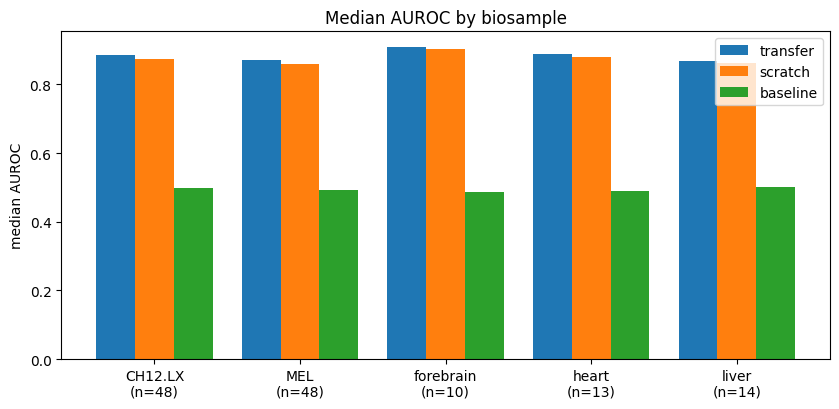

% ---- LaTeX (median AUROC by biosample) ----
\begin{tabular}{lccccc}
\toprule
Condition & CH12.LX (n=48) & MEL (n=48) & forebrain (n=10) & heart (n=13) & liver (n=14) \\
\midrule
transfer & 0.887 & 0.871 & 0.909 & 0.890 & 0.869 \\
scratch & 0.874 & 0.859 & 0.904 & 0.879 & 0.861 \\
baseline & 0.499 & 0.493 & 0.487 & 0.491 & 0.501 \\
\bottomrule
\end{tabular}


In [ ]:
# ---- median AUROC by biosample, per condition ----
# Is the transfer benefit uniform across cell types, or concentrated? Note the
# tiny-n biosamples (forebrain, heart) give noisier medians.
biosample = np.array([f.split("|")[0] for f in common])
bios = sorted(set(biosample))
fig, ax = plt.subplots(figsize=(8.5, 4.2))
names = list(results); width = 0.8 / len(names); x = np.arange(len(bios))
for i, name in enumerate(names):
    a = auroc_for(name)
    meds = [np.median(a[biosample == b]) if (biosample == b).any() else np.nan for b in bios]
    ax.bar(x + i*width, meds, width, label=name)
ax.set_xticks(x + width*(len(names)-1)/2)
ax.set_xticklabels([f"{b}\n(n={int((biosample == b).sum())})" for b in bios])
ax.set_ylabel("median AUROC"); ax.set_title("Median AUROC by biosample")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "compare_by_biosample.png"), dpi=150); plt.show()

print("% ---- LaTeX (median AUROC by biosample) ----")
print("\\begin{tabular}{l" + "c" * len(bios) + "}")
print("\\toprule")
print("Condition & " + " & ".join(f"{b} (n={int((biosample == b).sum())})" for b in bios) + " \\\\")
print("\\midrule")
for name in results:
    a = auroc_for(name)
    cells = " & ".join(f"{np.median(a[biosample == b]):.3f}" if (biosample == b).any() else "--"
                       for b in bios)
    print(f"{name} & {cells} \\\\")
print("\\bottomrule"); print("\\end{tabular}")

## Step 7 &mdash; sample-efficiency curve (the strongest argument for transfer)

Retrain **transfer** and **scratch** on increasing fractions of the training
windows (1% &rarr; 100%) and plot held-out median AUROC vs. training-set size.
Transfer's selling point is data efficiency: a warm-started trunk should match
full-scratch accuracy with a fraction of the data, which for a cross-species
story is more compelling than the final-point gap.

**This is the expensive cell** &mdash; it trains two models per fraction. The
sweep cell saves `sample_efficiency.npz`, and the plot cell is separate so you
can re-style the figure without re-running the sweep. The 100% point reuses the
Step-4 run, so it adds no extra training.

In [ ]:
# ---- sample-efficiency sweep: retrain transfer & scratch on data fractions ----
# Reuses build_model / train_model / evaluate. train_model reads `tr_i` (for
# pos_weight) and `train_dl` as globals, so we temporarily rebind both to the
# subsampled split, then restore the real split at the end.
FRACTIONS = [0.01, 0.05, 0.10]
SE_EPOCHS = 10                                   # same budget as the Step-4 run

rng = np.random.default_rng(SEED)
_tr_full = tr_i.copy()                            # preserve the true training split
se = {"transfer": [], "scratch": []}
se_sizes = []
for frac in FRACTIONS:
    if frac >= 1.0:
        sub = _tr_full
    else:
        k = max(BATCH * 2, int(len(_tr_full) * frac))
        sub = rng.choice(_tr_full, size=k, replace=False)
    se_sizes.append(int(len(sub)))
    globals()["tr_i"]     = sub
    globals()["train_dl"] = loader(sub, True)
    print(f"\n--- fraction {frac:.0%}  ({len(sub):,} windows) ---")
    for cond, use_human in (("transfer", True), ("scratch", False)):
        if frac >= 1.0 and cond in results:       # reuse the Step-4 full-data result
            med = float(np.median(results[cond]["auroc"]))
            print(f"  {cond:8s} median AUROC {med:.3f}  (reused from Step 4)")
        else:
            model = build_model(use_human)
            train_model(model, SE_EPOCHS)
            _, _, auroc, _, _ = evaluate(model)
            med = float(np.median(auroc))
            print(f"  {cond:8s} median AUROC {med:.3f}")
            del model
            if device == "cuda": torch.cuda.empty_cache()
        se[cond].append(med)

globals()["tr_i"]     = _tr_full                  # restore the real split
globals()["train_dl"] = loader(_tr_full, True)

np.savez(os.path.join(OUTPUT_DIR, "sample_efficiency.npz"),
         fractions=np.array(FRACTIONS), n_windows=np.array(se_sizes),
         transfer=np.array(se["transfer"]), scratch=np.array(se["scratch"]))
print("\nsaved sample_efficiency.npz ->", OUTPUT_DIR)


--- fraction 1%  (9,449 windows) ---
  human trunk loaded
  epoch  1  train 1.1720  val 1.0344  val_AUROC 0.716  lr 1.00e-03
  epoch  2  train 1.0094  val 1.2018  val_AUROC 0.719  lr 1.00e-03
  epoch  3  train 0.8783  val 0.9733  val_AUROC 0.730  lr 1.00e-03
  epoch  4  train 0.7506  val 1.0028  val_AUROC 0.720  lr 1.00e-03
  epoch  5  train 0.6512  val 1.0140  val_AUROC 0.714  lr 1.00e-03
  epoch  6  train 0.5641  val 1.2832  val_AUROC 0.710  lr 5.00e-04
  early stop at epoch 6 (best val 0.9733)
  restored best model (val loss 0.9733)
  transfer median AUROC 0.733
  random trunk (scratch)
  epoch  1  train 1.2117  val 1.1214  val_AUROC 0.662  lr 1.00e-03
  epoch  2  train 1.1273  val 1.4287  val_AUROC 0.670  lr 1.00e-03
  epoch  3  train 1.0669  val 1.4351  val_AUROC 0.690  lr 1.00e-03
  epoch  4  train 1.0239  val 3.3260  val_AUROC 0.707  lr 5.00e-04
  early stop at epoch 4 (best val 1.1214)
  restored best model (val loss 1.1214)
  scratch  median AUROC 0.681

--- fraction 5%  (47,

ValueError: x and y must have same first dimension, but have shapes (4,) and (3,)

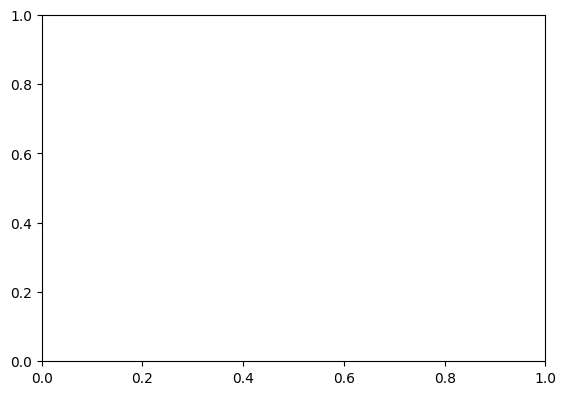

In [ ]:
# ---- sample-efficiency curve: median AUROC vs training-set size ----
# Reads from memory if the sweep just ran; otherwise loads the saved npz.
if "se" not in globals():
    z = np.load(os.path.join(OUTPUT_DIR, "sample_efficiency.npz"))
    se = {"transfer": list(z["transfer"]), "scratch": list(z["scratch"])}
    se_sizes = list(z["n_windows"])

plt.figure(figsize=(6.5, 4.5))
plt.plot(se_sizes, se["transfer"], "-o", color="#d62728", label="transfer")
plt.plot(se_sizes, se["scratch"],  "-o", color="#1f77b4", label="scratch")
plt.axhline(se["scratch"][-1], color="#1f77b4", ls=":", lw=1, alpha=.7,
            label=f"scratch @ 100% = {se['scratch'][-1]:.3f}")
plt.xscale("log")
plt.xlabel("training windows (log scale)"); plt.ylabel("test median AUROC")
plt.title("Sample efficiency: transfer vs scratch")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "compare_sample_efficiency.png"), dpi=150); plt.show()

# how little data does transfer need to match scratch trained on 100%?
target = se["scratch"][-1]
hit = next((n for n, v in zip(se_sizes, se["transfer"]) if v >= target), None)
if hit is not None:
    print(f"transfer matches scratch@100% AUROC ({target:.3f}) with {hit:,} windows "
          f"= {hit/se_sizes[-1]:.0%} of the training data.")
else:
    print(f"transfer did not reach scratch@100% AUROC ({target:.3f}) at any tested fraction.")

## Reloading saved weights later

The cell below shows how to load any saved condition back for inference or more
analysis (e.g. inspecting the transferred conv filters). It does not run by
default.

In [ ]:
# name = "transfer"
# model = DeepSEATransfer(F, pool=TRUNK_POOL).to(device)
# model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, f"{name}_model.pt"), map_location=device))
# model.eval()
# probs, ytrue, auroc, auprc, kept = evaluate(model)
# print(name, "median AUROC", float(np.median(auroc)))

## Appendix: the canonical Selene config (optional from-scratch baseline)

Selene is the original authors' library for retraining DeepSEA-style models from
a YAML config. `selene-sdk` pins older deps and compiles Cython, so it often
won't build on current Colab &mdash; that failure is expected and the notebook
path above does not depend on it.

In [ ]:
selene_yaml = '''
---
ops: [train, evaluate]
model:
  path: ./deepsea.py
  class: DeepSEA
  class_args:
    sequence_length: 1000
    n_targets: N_FEATURES
  non_strand_specific: mean
sampler: !obj:selene_sdk.samplers.IntervalsSampler
  reference_sequence: !obj:selene_sdk.sequences.Genome
    input_path: ./mouse_encode_data/genome/chr19.fa
  features: !obj:selene_sdk.utils.load_features_list
    input_path: ./mouse_encode_data/selene/distinct_features.txt
  target_path: ./mouse_encode_data/selene/mouse_peaks.bed.gz
  intervals_path: ./mouse_encode_data/selene/mouse_peaks.bed
  seed: 0
  sequence_length: 1000
  center_bin_to_predict: 200
  test_holdout: [chr19]
  validation_holdout: [chr18]
  feature_thresholds: 0.5
train_model: !obj:selene_sdk.TrainModel
  batch_size: 128
  max_steps: 16000
  report_stats_every_n_steps: 2000
  n_validation_samples: 4096
  cpu_n_threads: 4
  use_cuda: true
  data_parallel: false
random_seed: 0
output_dir: ./selene_out
create_subdirectory: true
'''
with open("mouse_transfer.yml", "w") as f:
    f.write(selene_yaml.replace("N_FEATURES", str(F)))
print("wrote mouse_transfer.yml  (run with:  selene_cli.py mouse_transfer.yml )")

wrote mouse_transfer.yml  (run with:  selene_cli.py mouse_transfer.yml )
